# 5. Trees

Stem detection and DBH, segmentation of the cloud into trees, heights and
crown metrics. Everything here works on a height-normalised cloud (notebook 4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import ground, trees

cloud = ground.classify_ground_csf(synthetic.forest().without("classification"))
cloud = ground.normalize_height(cloud, ground.make_dtm(cloud, 0.5))

## Stems

`detect_stems` fits RANSAC circles in horizontal slices around breast height, links them vertically into stems, and reports DBH at 1.3 m with quality measures.

In [2]:
stems = trees.detect_stems(cloud)
print(f"{'id':>2} {'x':>6} {'y':>6} {'dbh':>6} {'cover':>6} {'slices':>6} {'quality':>7}")
for t in stems:
    print(f"{t.tree_id:>2} {t.x:6.2f} {t.y:6.2f} {t.dbh:6.3f} {t.inlier_fraction:6.2f} {t.n_slices:>6} {t.quality:7.2f}")
print("\ntruth (x, y, dbh):", [(x, y, d) for x, y, d, _ in synthetic.DEFAULT_TREES])

id      x      y    dbh  cover slices quality
 1  15.50  15.00  0.237   1.00     17    0.76
 2   5.00   5.00  0.287   1.00     17    0.76
 3  14.00   6.00  0.185   1.00     17    0.76
 4   8.00  15.00  0.438   1.00     17    0.76

truth (x, y, dbh): [(5.0, 5.0, 0.3), (14.0, 6.0, 0.2), (8.0, 15.0, 0.45), (15.5, 15.0, 0.25)]


## Segmentation

Every point is assigned to a stem by shortest path over a neighbourhood graph, then heights are measured and spurious candidates pruned.

In [3]:
labels = trees.segment_trees(cloud, stems)
trees.tree_heights(cloud, labels, stems)
stems, labels = trees.prune_trees(stems, labels)
crowns = trees.crown_metrics_all(cloud, labels)
for t in stems:
    c = crowns[t.tree_id]
    print(f"tree {t.tree_id}: DBH {t.dbh:.3f} m, height {t.height:5.2f} m, crown area {c['crown_area']:5.1f} m2, "
          f"crown base {c['crown_base_height']:.1f} m")

tree 1: DBH 0.438 m, height 17.28 m, crown area  81.8 m2, crown base 4.0 m
tree 2: DBH 0.287 m, height 13.20 m, crown area  51.6 m2, crown base 3.0 m
tree 3: DBH 0.237 m, height 13.10 m, crown area  46.5 m2, crown base 3.0 m
tree 4: DBH 0.185 m, height 10.29 m, crown area  32.1 m2, crown base 2.5 m


vegetation points on the right tree: 95.1%


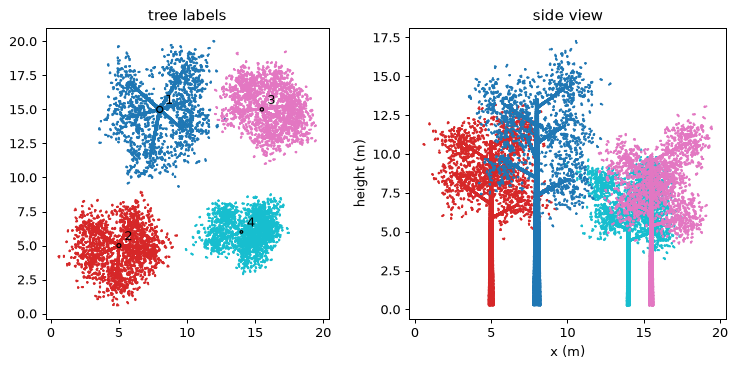

In [4]:
truth = synthetic.forest().attrs["tree_id"]
veg = truth > 0
match = {t.tree_id: np.bincount(truth[labels == t.tree_id]).argmax() for t in stems}
correct = np.mean([match.get(l, -1) == g for l, g in zip(labels[veg][::10], truth[veg][::10])])
print(f"vegetation points on the right tree: {correct:.1%}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
m = labels > 0
ax[0].scatter(cloud.x[m][::3], cloud.y[m][::3], c=labels[m][::3], s=0.4, cmap="tab10")
for t in stems:
    ax[0].add_patch(plt.Circle((t.x, t.y), t.dbh / 2, fill=False, color="k"))
    ax[0].annotate(str(t.tree_id), (t.x + 0.4, t.y + 0.4))
ax[0].set(title="tree labels", aspect="equal")
ax[1].scatter(cloud.x[m][::3], cloud.attrs["height"][m][::3], c=labels[m][::3], s=0.4, cmap="tab10")
ax[1].set(title="side view", xlabel="x (m)", ylabel="height (m)");

## Taper

`dbh_profile` fits circles up the stem.

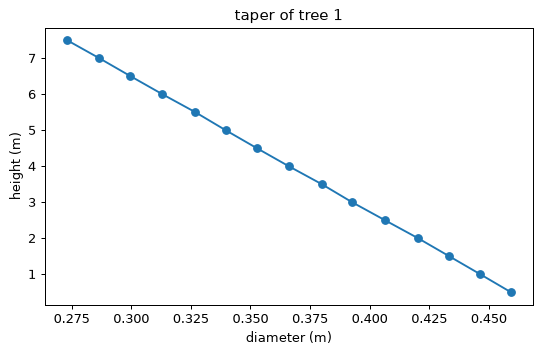

In [5]:
big = max(stems, key=lambda t: t.dbh)
heights = np.arange(0.5, 8.0, 0.5)
diam = trees.dbh_profile(cloud, (big.x, big.y), heights=heights)
plt.plot(diam[:, 1], diam[:, 0], "o-")
plt.gca().set(xlabel="diameter (m)", ylabel="height (m)", title=f"taper of tree {big.tree_id}");

Save the result: `sylva.write(cloud.with_attrs(tree_id=labels), 'plot_trees.laz')`.